<a href="https://colab.research.google.com/github/July230/AviDetect/blob/develop/AviDetectClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [42]:
!pip install split-folders

In [75]:
import os
import shutil
import splitfolders
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Path de Google Drive

In [46]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Usaremos el dataset [Drone vs Bird:Aerial Object Classification Dataset](https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird) disponible públicamente [Kaggle](https://www.kaggle.com) bajo la licencia **Apache 2.0**.

Podemos importar el dataset vía kagglehub.

In [47]:
# Download latest version
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'drone-vs-bird' dataset.
Path to dataset files: /kaggle/input/drone-vs-bird


El dataset tiene dos carpetas con 4106 imágenes en total:
* bird: 1607 imágenes
* drone: 2499 imágenes

Es necesario hacer el split inicial para obtener train y test. Posteriormente, dividir train en train y validation. Las divisiones comunes para esta división son 70/15/15 u 80/10/10.
Haremos una división de 70% train, 15% validation y 15% test.

In [48]:
def removeDirectories(parentDirectory, directoriesToRemove):
  """
  Remove the directories of a parent directory

  Parameters
  ----------
  parentDirectory : str
    Path to the parent directory you want to clean
  directoriesToRemove : list
    List of the directories to clean

  Returns
  -------
  None
  """
  for directory in directoriesToRemove:
    directoryPath = os.path.join(parentDirectory, directory)
    if os.path.exists(directoryPath):
      shutil.rmtree(directoryPath)
      print(f"Deleted: {directoryPath}")

Tomaremos el dataset de kaggle y el dataset resultado (spliteado) estará en el directorio BirdVSDrone

In [49]:
SEED = 42
datasetDirectory = os.path.join(path, "dataset")
outputDirectory = "/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone"

In [50]:
!ls {datasetDirectory}

bird  drone


In [ ]:
directoriesToRemove = ["train", "test", "val"]
removeDirectories(outputDirectory, directoriesToRemove)

Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/train
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/test
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/val


La librería splitfolders nos permite hacer el split de manera sencilla

In [ ]:
splitfolders.ratio(datasetDirectory, output=outputDirectory, seed=SEED, ratio=(0.7, 0.15, 0.15))

Copying files: 4106 files [00:52, 78.40 files/s]


In [51]:
!ls {outputDirectory}

test  train  val


Dato curioso: La semilla 42 se usa en ocasiones como tradición de programadores y científicos de datos. Aparece de la novela de ciencia ficción de Douglas Adams: *La guía del autoestopista galáctico (1979)*. Aquí, la supercomputadora llamada *Deep though* revela que la respuesta a la gran pregunta de "la vida, el universo y todo lo demás" es 42. Realmente no tiene alguna ventaja computacional.

Verificamos que existan las imagenes

In [52]:
def countImages(directory, directories):
  """
  Count the number of images in a directory

  Parameters
  ----------
  directory : str
    Path to the directory where the images are
  directories : list
    Directories train, test and val that have bird and drone each

  Returns
  -------
  None
  """
  for directory in directories:
    print(f"Images in {directory}:")
    for subdirectory in ["bird", "drone"]:
      totalImages = len(os.listdir(os.path.join(outputDirectory, directory, subdirectory)))
      print(f"{subdirectory}: {totalImages}")

In [53]:
directoriesWithImages = ["train", "test", "val"]
countImages(outputDirectory, directoriesWithImages)

Images in train:
bird: 1749
drone: 1749
Images in test:
bird: 242
drone: 376
Images in val:
bird: 241
drone: 374


Visualizamos las imagenes que hay en train

In [54]:
trainDirectory = os.path.join(outputDirectory, "train")
testDirectory = os.path.join(outputDirectory, "test")
valDirectory = os.path.join(outputDirectory, "val")

In [55]:
def getImages(directory, numImages, seed=42):
  """
  Get the images from a directory and show them

  Parameters
  ----------
  directory : str
    Path to the directory that contains the train set
  numImages : int
    Images to show

  Returns
  -------
  None
  """

  np.random.seed(seed)

  plt.figure(figsize=(10,10))
  images = [i for i in os.listdir(directory) if os.path.isfile(os.path.join(directory, i))]
  np.random.shuffle(images)
  images = images[:numImages]

  for i, image in enumerate(images):
    img = plt.imread(os.path.join(directory, image))
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img, cmap=plt.cm.binary)

  plt.show()

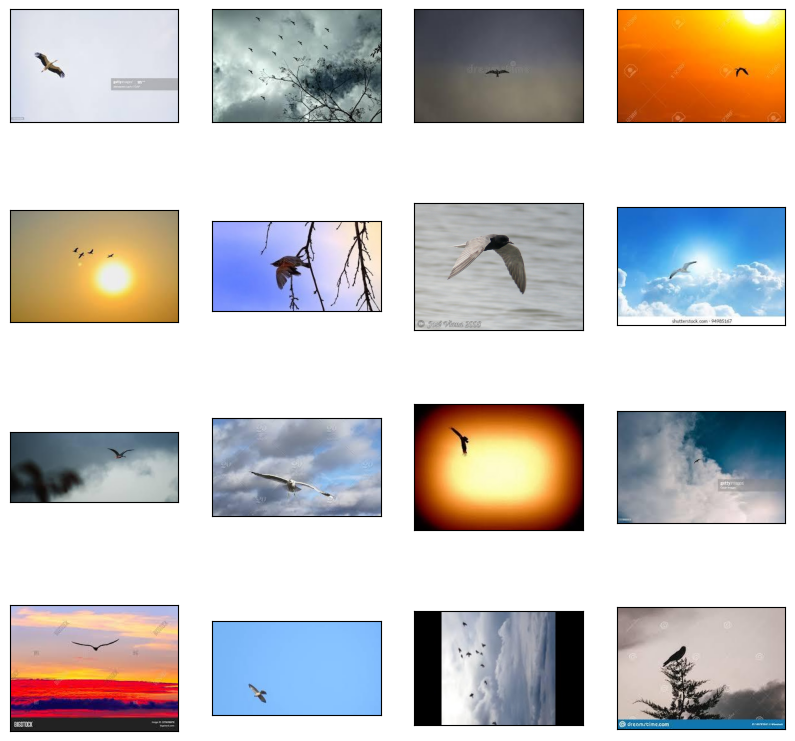

In [56]:
getImages(os.path.join(trainDirectory, "bird"), 16, SEED)

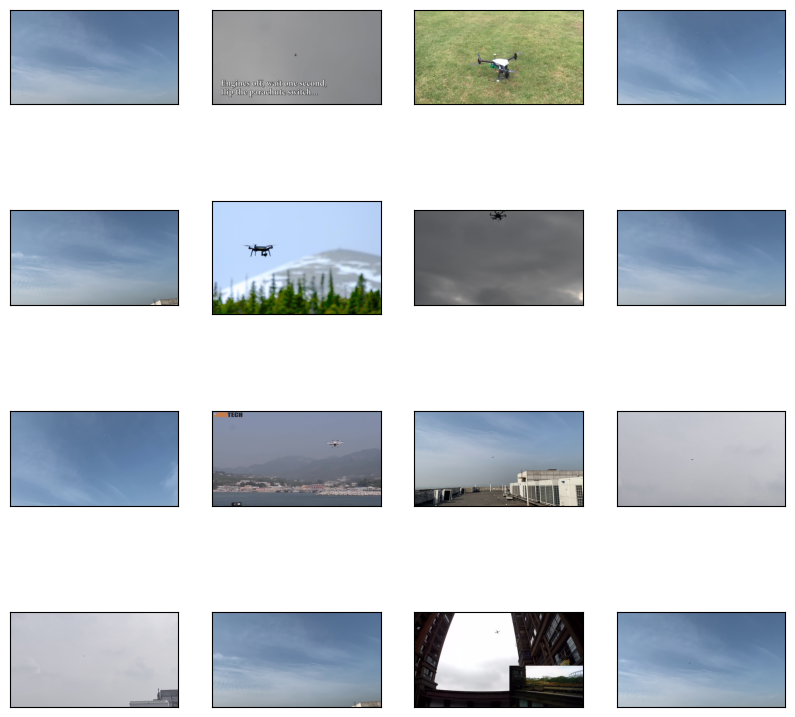

In [57]:
getImages(os.path.join(trainDirectory, "drone"), 16, SEED)

# Desbalanceo de clases y data augmentation
El dataset contiene más imágenes de drones que de aves, lo que puede derivar en que el modelo aprenda más a identificar drones que aves.
Para mitigar el desbalanceo de clases, se consideró una técnica de oversampling sobre la clase minoritaria, seguido de data augmentation a todas las clases, siguiendo enfoques similares a los propuestos por Guerrero et al. (2024), donde la aumentación dirigida permitió reducir el sesgo hacia las clases mayoritarias en tareas de clasificación de imágenes.
Es importante destacar que estas alteraciones en el dataset se hacen únicamente en el set de entrenamiento. Los set de validation y test se dejan como están.

Se realizó un oversampling aleatorio. Se calcularon las imágenes faltantes, seleccionando la misma cantidad aleatoriamente y duplicando cada imagen una vez.

In [58]:
def oversample(directory, minorClass, mayorClass, seed=42):
  """
  Selects images randomly and copies in the same directory

  Parameters
  ----------
  directory : str
    Path to the directory that contains the train set
  minorClass : str
    Minority class foldername
  mayorClass : str
    Mayority class foldername
  seed : int
    Random seed

  Returns
  -------
  None
  """

  mayorClassPath = os.path.join(directory, mayorClass)
  minorClassPath = os.path.join(directory, minorClass)

  mayorImages = sorted([i for i in os.listdir(mayorClassPath) if os.path.isfile(os.path.join(mayorClassPath, i))])
  minorImages = sorted([i for i in os.listdir(minorClassPath) if os.path.isfile(os.path.join(minorClassPath, i))])

  lenMayorImages = len(mayorImages)
  lenMinorImages = len(minorImages)
  imagesNeeded = lenMayorImages - lenMinorImages

  print(f"{mayorClass}: {lenMayorImages}")
  print(f"{minorClass}: {lenMinorImages}")
  print(f"Need to generate: {imagesNeeded}")

  if mayorImages == []:
    print(f"{mayorImages} has no images.")
    return

  if minorImages == []:
    print(f"{minorClassPath} has no images.")
    return

  if imagesNeeded <= 0:
    print(f"Dataset already balanced.")
    return

  np.random.seed(seed)
  selectedImages = np.random.choice(minorImages, size=imagesNeeded, replace=True)

  for index, image in enumerate(selectedImages):
    sourcePath = os.path.join(minorClassPath, image)
    filename, extension = os.path.splitext(image)
    newFileName = f"{filename}_copy_{index}{extension}"
    destinationPath = os.path.join(minorClassPath, newFileName)
    shutil.copy2(sourcePath, destinationPath)
  print(f"Generated {imagesNeeded} oversampled images in {minorClassPath}")


In [59]:
oversample(trainDirectory, 'bird', 'drone', seed=SEED)

drone: 1749
bird: 1749
Need to generate: 0
Dataset already balanced.


Verificamos que se haya hecho el oversampling en train

In [60]:
countImages(outputDirectory, directoriesWithImages)

Images in train:
bird: 1749
drone: 1749
Images in test:
bird: 242
drone: 376
Images in val:
bird: 241
drone: 374


# Data augmentation
Después de aplicar oversampling, se usa ImageDataGenerator para generar imagenes nuevas en el ram mientras se entrena para no desperdiciar espacio. Un problema de tamaño limitado de se presentó a los autores Rares Ilie Orzan et al (2024) donde contaban con una cantidad limitada de imágenes (106) para su estudio. Aplicaron una serie de transformaciones a las imágenes para combatir la falta de datos.

In [61]:
# Constants
IMAGEWIDTH = 224
IMAGEHEIGHT = 224
BATCHSIZE = 10
ROTATIONRANGE = 30
TRANSLATIONS = 0.1
SCALING = [0.9, 1.1]
EPOCHS = 14

In [62]:
trainDatagen = ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = ROTATIONRANGE,
    width_shift_range = TRANSLATIONS,
    height_shift_range = TRANSLATIONS,
    zoom_range = SCALING,
    horizontal_flip = True,
    vertical_flip = False)

Para ello se asigna una fuente base de imágenes a modificar, se toman sólo las del directorio de train. En este caso sólo se toma una imagen y se muestra como se generarían 5 imágenes diferentes.

Found 3495 images belonging to 2 classes.


<Figure size 640x480 with 0 Axes>

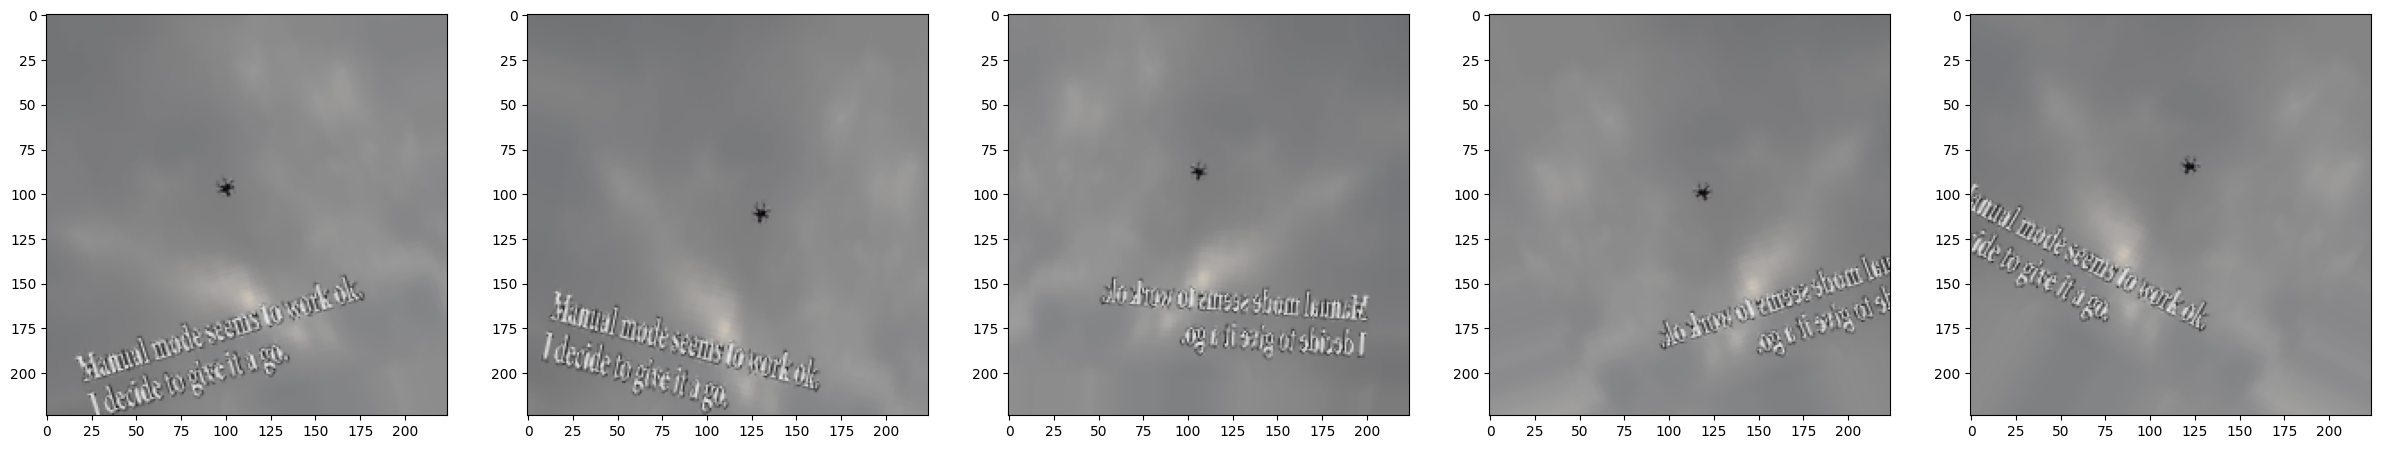

In [63]:
trainGenerator = trainDatagen.flow_from_directory(
    trainDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE, # Images that the models gets in each iteration
    class_mode = "binary") # Has to be the same on the last neuron of the model

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(trainGenerator[0][0][0])

(10, 224, 224, 3)
[1. 0. 1. 0. 1. 0. 1. 0. 1. 1.]


<Figure size 640x480 with 0 Axes>

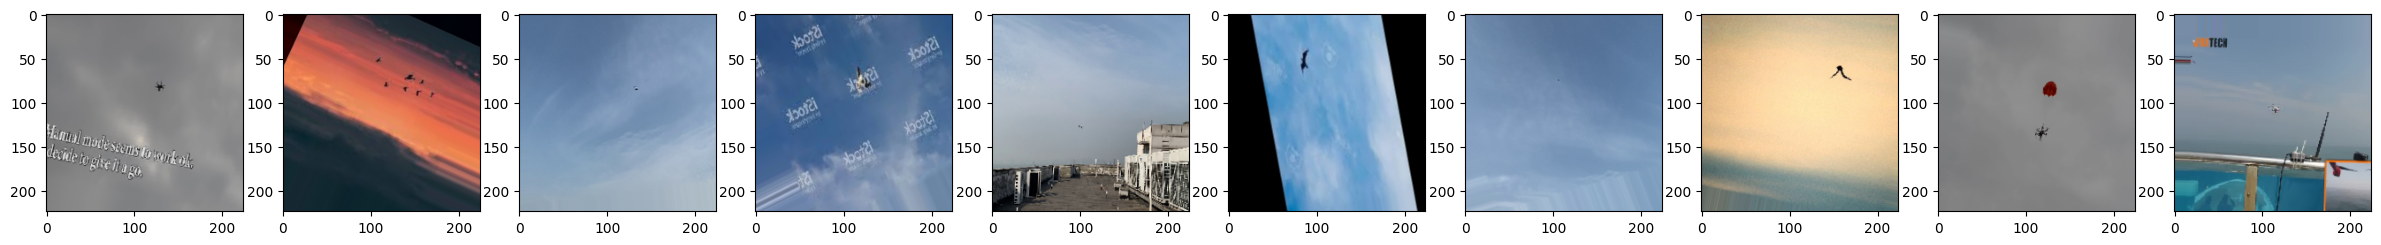

In [64]:
images , labels = trainGenerator[0]

print(images.shape)
print(labels)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 4))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

# Primera Red Neuronal Convolutiva (CNN)
Se crea la red neuronal convolutiva. Con la capa convolutiva se convierten las características de dos dimensiones (las imágenes) en matrices con las características más singnificativas. Posteriormente se convierte en un vector de una dimensión.

Este modelo se hizo basado en la documentación de tensorflow. Las dimensiones de ancho y alto tienden a reducirse a medida que se profundiza en la red. El número de canales de salida para cada capa Conv2D está controlado por el primer argumento.

In [65]:
ThreeLayerCNN = models.Sequential()
ThreeLayerCNN.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
ThreeLayerCNN.add(layers.MaxPooling2D((2, 2)))
ThreeLayerCNN.add(layers.Conv2D(64, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
ThreeLayerCNN.add(layers.MaxPooling2D((2, 2)))
ThreeLayerCNN.add(layers.Conv2D(128, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
ThreeLayerCNN.add(layers.MaxPooling2D((2, 2)))
ThreeLayerCNN.add(layers.Flatten())
ThreeLayerCNN.add(layers.Dense(128,activation="relu"))
ThreeLayerCNN.add(layers.Dense(1,activation="sigmoid"))

ThreeLayerCNN.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
ThreeLayerCNN.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"])

In [67]:
history = ThreeLayerCNN.fit(trainGenerator, epochs = EPOCHS)

accuracy = history.history["accuracy"]
loss = history.history["loss"]

epochs = range(1, len(accuracy)+1)

Epoch 1/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 325s 921ms/step - accuracy: 0.7019 - loss: 0.5479
Epoch 2/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 312s 891ms/step - accuracy: 0.8137 - loss: 0.3966
Epoch 3/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 325s 897ms/step - accuracy: 0.8340 - loss: 0.3649
Epoch 4/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 309s 881ms/step - accuracy: 0.8621 - loss: 0.3215
Epoch 5/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 324s 923ms/step - accuracy: 0.8701 - loss: 0.3051
Epoch 6/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 320s 915ms/step - accuracy: 0.8770 - loss: 0.2865
Epoch 7/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 312s 891ms/step - accuracy: 0.8898 - loss: 0.2743
Epoch 8/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 324s 926ms/step - accuracy: 0.8853 - loss: 0.2632
Epoch 9/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 370s 890ms/step - accuracy: 0.9004 - loss: 0.2543
Epoch 10/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 314s 896ms/step - accuracy: 0.9041 - loss: 0.2308
Epoch 11/14
350/350 ━━━━━━━━━━━━━━━━━━━━ 319s 910ms/step - accuracy: 0.9090 - loss: 0.2208
Epoch 12

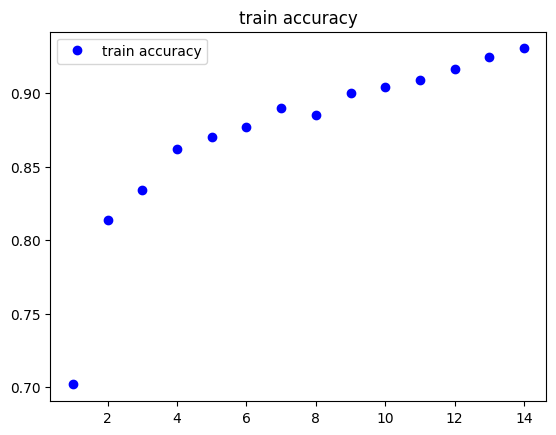

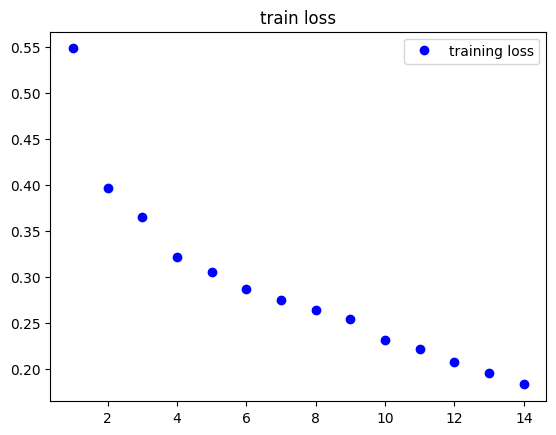

In [68]:
plt.plot(epochs, accuracy, "bo", label="train accuracy")
plt.title("train accuracy")
plt.legend()

plt.figure()

plt.plot(epochs, loss, "bo", label ="training loss")
plt.title("train loss")
plt.legend()

plt.show()

Con validation sólo se prueba con lo real, sin embargo, sí se escala.

In [69]:
valDatagen = ImageDataGenerator(1.0/255)
valGenerator = valDatagen.flow_from_directory(
    valDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode = "binary")

valLoss, valAccuracy = ThreeLayerCNN.evaluate(valGenerator, steps = 25)
print("\nval accuracy :\n", valAccuracy)

Found 615 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 342ms/step - accuracy: 0.3760 - loss: 1171.3690

val accuracy :
 0.37599998712539673


Con test sólo queremos lo real, por eso aqui siempre sólo se escala

In [70]:
testDatagen = ImageDataGenerator(1.0/255)
testGenerator = testDatagen.flow_from_directory(
    testDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode= "binary")

testLoss, testAccuracy = ThreeLayerCNN.evaluate(testGenerator, steps = 25)
print("\ntest acc :\n", testAccuracy)

Found 618 images belonging to 2 classes.
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 303ms/step - accuracy: 0.3400 - loss: 1267.3721

test acc :
 0.3400000035762787


# Comparando resultados

El estado del arte en el problema de clasificación de aves y drones es un acuracy mayor al 90%.

In [77]:
def confusionMatrix(model, setGenerator):
  """
  Creates the confusion matrix based on real and predicted labels

  Parameters
  ----------
  model :
  setGenerator :

  Returns
  -------
  mat : np.ndarray
    Confusion matrix
  """
  predictions = model.predict(setGenerator)
  trueLabels = setGenerator.classes
  predictedClasses = (predictions > 0.5).astype(int).flatten()
  matrix = confusion_matrix(trueLabels, predictedClasses)

  print("\t\t", "label negative", "label positive")
  print("prediction negative\t", np.array(matrix[0][0]), "\t", np.array(matrix[0][1]))
  print("prediction positive\t", np.array(matrix[1][0]), "\t", np.array(matrix[1][1]))

  return matrix

def displayConfusionMatrix(confusionMatrix):
  """
  Displays the confusion matrix

  Parameters
  ----------
  confusionMatrix : np.ndarray
    Confusion matrix

  Returns
  -------
  None
  """
  display = ConfusionMatrixDisplay(
      confusion_matrix=confusionMatrix,
      display_labels=["Bird", "Drone"])
  display.plot()
  plt.title("Confusion matrix")
  plt.show()

def metrics(confusionMatrix):
  """
  Calculates the metrics based on the confusion matrix
  Precision, Recall and F1-score

  Parameters
  ----------
  confusionMatrix : np.ndarray
    Confusion matrix

  Returns
  -------
  None
  """
  truePositives = confusionMatrix[1][1]
  trueNegatives = confusionMatrix[0][0]
  falsePositives = confusionMatrix[0][1]
  falseNegatives = confusionMatrix[1][0]

  precision = truePositives / (truePositives + falsePositives)
  recall = truePositives / (truePositives + falseNegatives)
  f1Score = (2 * (precision * recall)) / (precision + recall)

  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1-score: {f1Score:.4f}")

## Primer modelo CNN

### Train

In [78]:
print("Model\t\t", "Train loss\t\t", "Train Accuracy\t")
print("Original\t", loss[-1:], "\t", accuracy[-1])

Model		 Train loss		 Train Accuracy	
Original	 [0.18271438777446747] 	 0.9304720759391785


In [79]:
confusionMatrixTrain = confusionMatrix(ThreeLayerCNN, trainGenerator)

350/350 ━━━━━━━━━━━━━━━━━━━━ 131s 373ms/step
		 label negative label positive
prediction negative	 906 	 840
prediction positive	 925 	 824


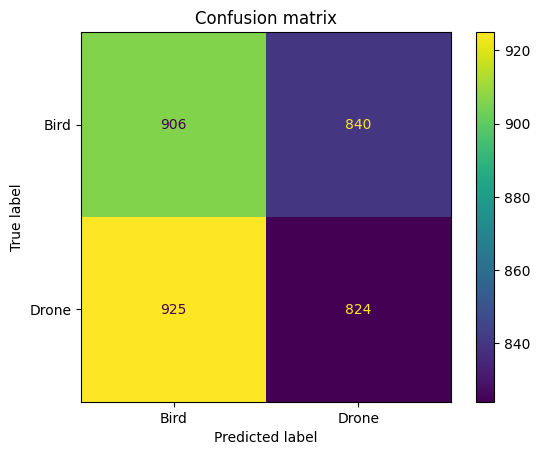

In [80]:
displayConfusionMatrix(confusionMatrixTrain)

In [81]:
metrics(confusionMatrixTrain)

Precision: 0.4952
Recall: 0.4711
F1-score: 0.4829


La metrica más baja es la precisión, algo esperado puesto que no acierta correctamente a la mayoría de las instancias de una clase, en este caso, bird. Es por esa razón que el recall es alto, ya que confunde mucho a la clase negativa. Como resultado, el F1-Score es muy bajo, al ser una media armónica de ambas métricas mencionadas, penaliza cuando una de las dos es baja.

### Validation

In [82]:
print("Model\t\t", "Val loss\t\t", "Val Accuracy\t")
print("Original\t", valLoss, "\t", valAccuracy)

Model		 Val loss		 Val Accuracy	
Original	 1171.3690185546875 	 0.37599998712539673


In [83]:
confusionMatrixVal = confusionMatrix(ThreeLayerCNN, valGenerator)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 343ms/step
		 label negative label positive
prediction negative	 241 	 0
prediction positive	 371 	 3


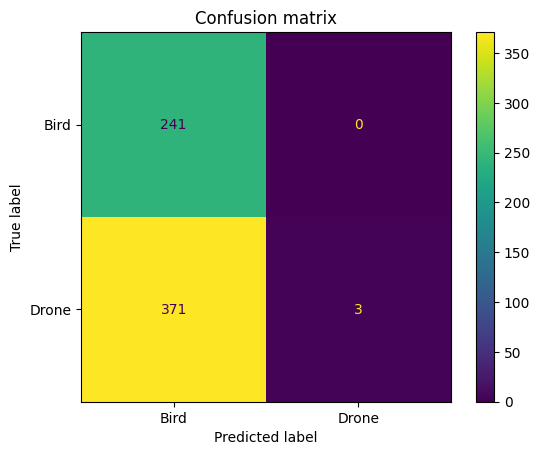

In [84]:
displayConfusionMatrix(confusionMatrixVal)

In [85]:
metrics(confusionMatrixVal)

Precision: 1.0000
Recall: 0.0080
F1-score: 0.0159


### Test

In [86]:
print("Model\t\t", "Test loss\t\t", "Test Accuracy\t")
print("Original\t", testLoss, "\t", testAccuracy)

Model		 Test loss		 Test Accuracy	
Original	 1267.3720703125 	 0.3400000035762787


In [87]:
confusionMatrixTest = confusionMatrix(ThreeLayerCNN, testGenerator)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


62/62 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step
		 label negative label positive
prediction negative	 242 	 0
prediction positive	 374 	 2


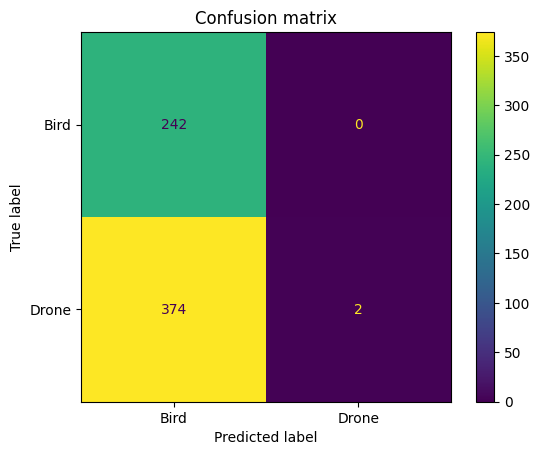

In [88]:
displayConfusionMatrix(confusionMatrixTest)

In [89]:
metrics(confusionMatrixTest)

Precision: 1.0000
Recall: 0.0053
F1-score: 0.0106
